In [1]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg, bmg_fast
from MISC_Functions import BICcherryRestrict
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid


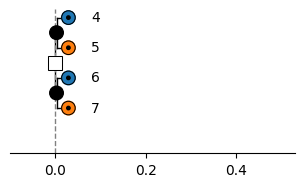

In [2]:
speciesTree, geneTree = MISC_Functions.generateTree(2,2)

# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

In [3]:
# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

print(nx.utils.graphs_equal(BMG, BMGBC))

die Lcas von 4 und 5 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 4 und 7 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 4 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 6 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 7 und 4 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 7 und 6 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 6 und 5 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 6 und 7 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 4 u

die Lcas von 4 und 5 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 4 und 7 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 4 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 6 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 7 und 4 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 7 und 6 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 6 und 5 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 6 und 7 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 4 u

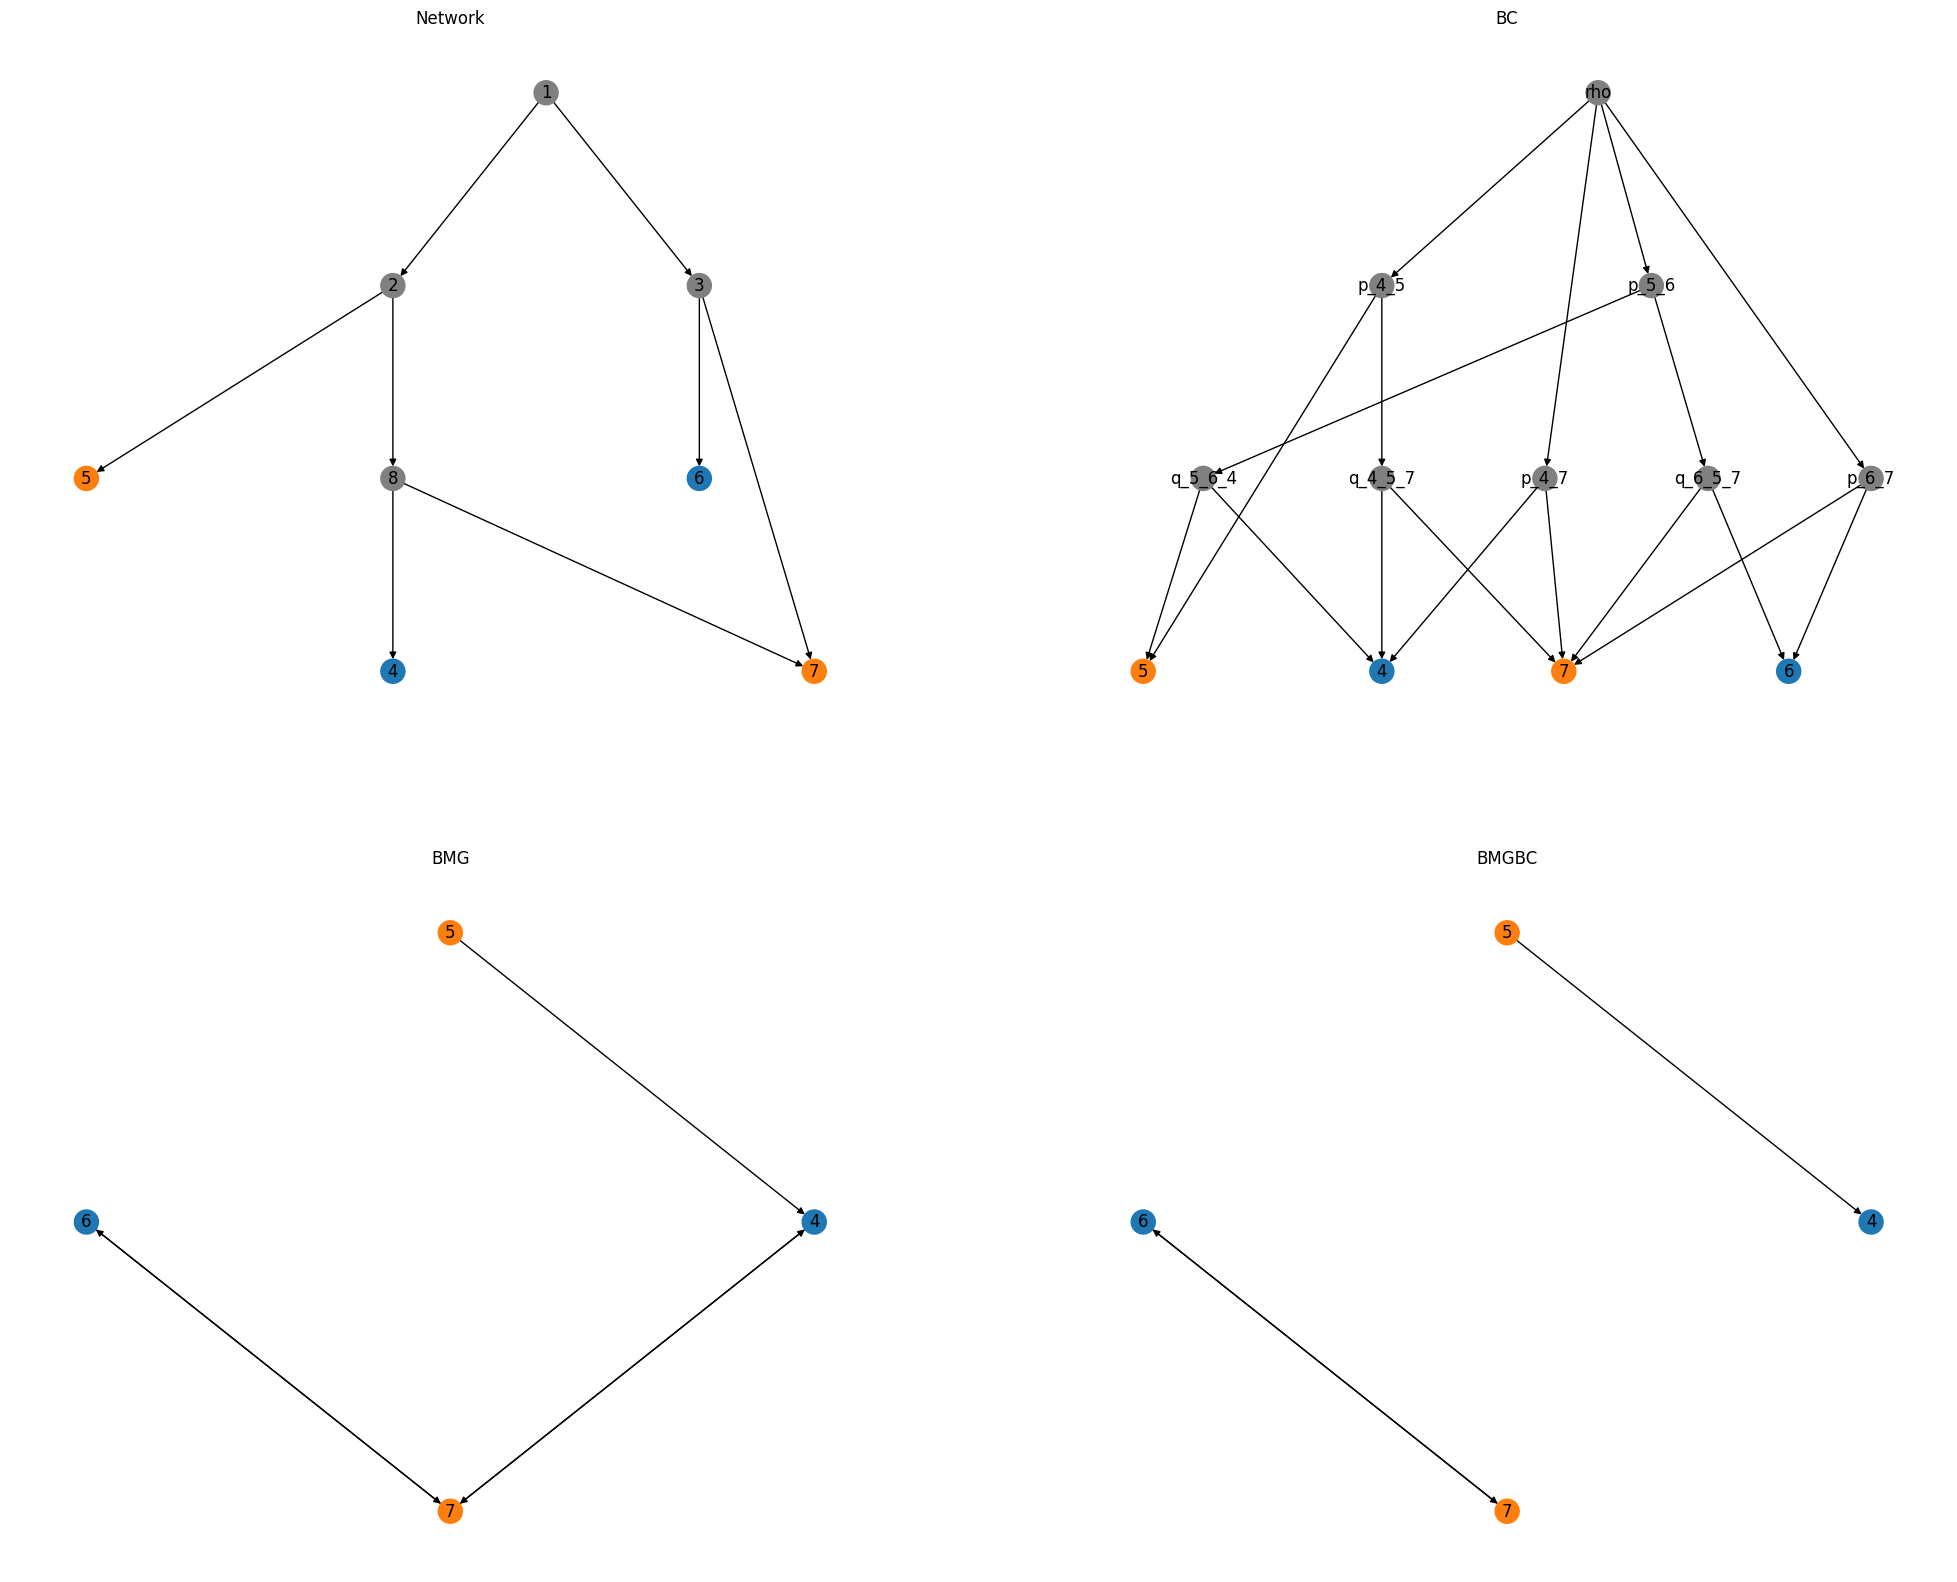

In [4]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
random.seed(2)
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg(Tree)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network = insertHybrid(Network)
    BMG = bmg(Network, mode = "strong")
    BC = BICcherryRestrict(BMG)
    BMGBC = bmg(BC, mode = "strong")
    count += 1
    if count % 10 == 0:
        print("Count = ",count)

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)


die Lcas von 4 und 5 sind {'2'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'2'}
die Lcas von 4 und 7 sind {'1'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'2'}
die Lcas von 5 und 4 sind {'2'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'2'}
die Lcas von 5 und 6 sind {'1'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'2'}
die Lcas von 6 und 5 sind {'1'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'3'}
die Lcas von 6 und 7 sind {'3'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'3'}
die Lcas von 7 und 4 sind {'1'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'3'}
die Lcas von 7 und 6 sind {'3'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'3'}
die Lcas von 4 und 5 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 4 und 7 sind {'p_4_7'}
die Menge der kleinen ancestors zw

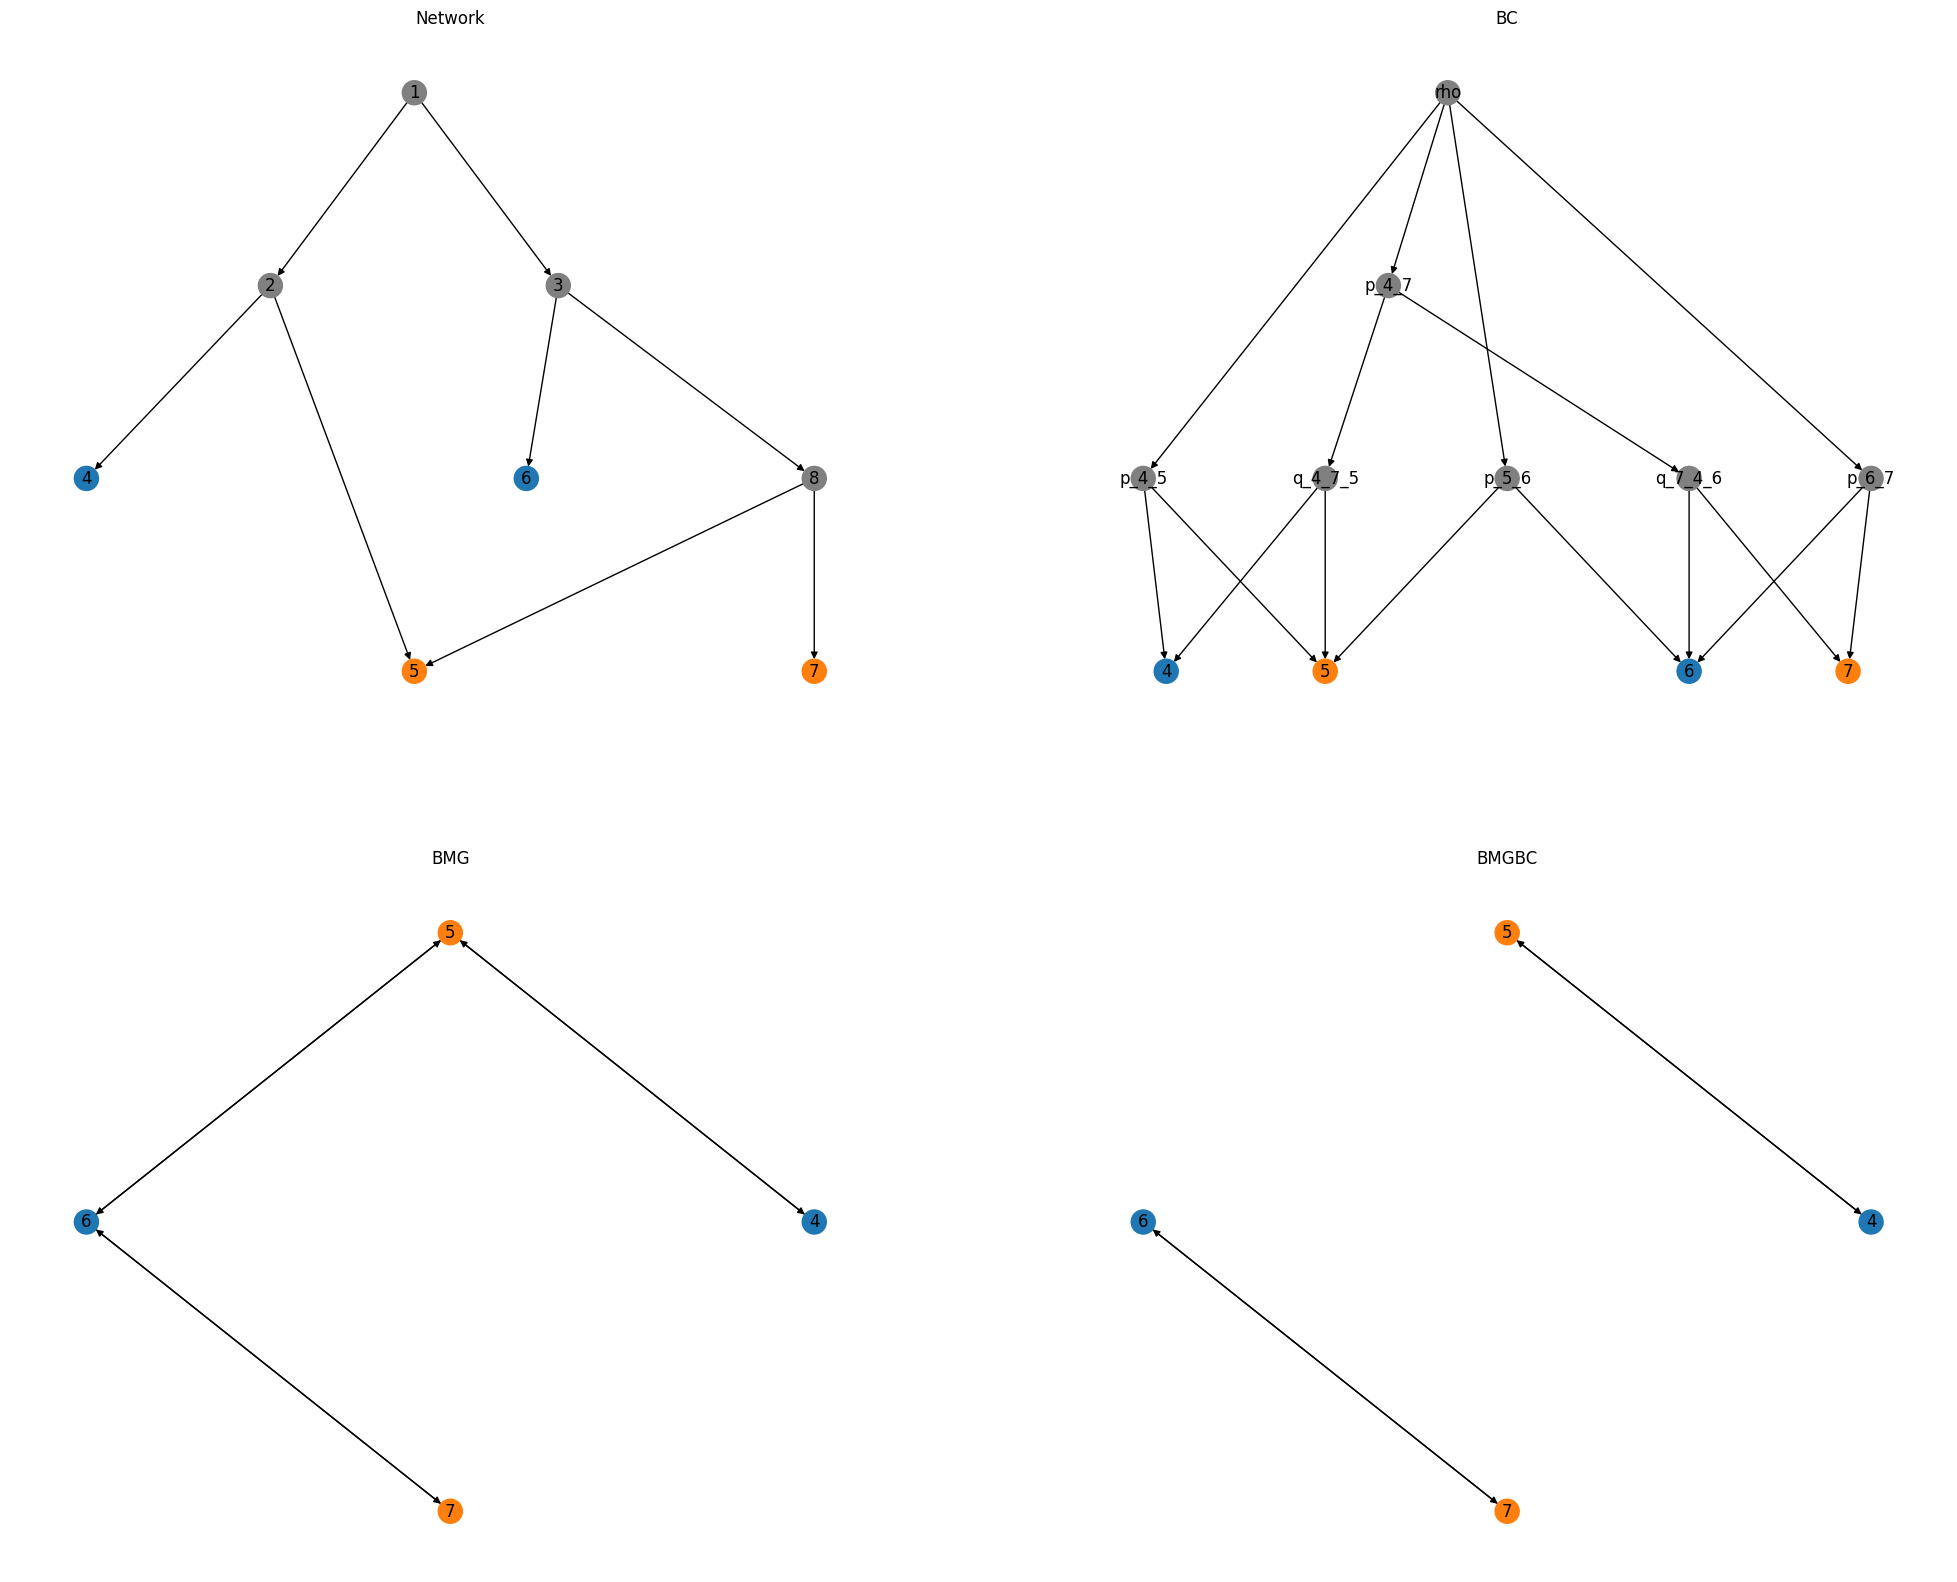

In [5]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg_fast(Tree)
BC = BICcherryRestrict(BMG)
BMGBC = bmg_fast(BC)
mode = "strong"

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network = insertHybrid(Network)
    BMG = bmg_fast(Network, mode = mode)
    BC = BICcherryRestrict(BMG)
    BMGBC = bmg_fast(BC, mode = mode)
    count += 1
    if count % 10 == 0:
        print("Count = ",count)

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)

die Lcas von 4 und 5 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 4 und 7 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 4 und Spezies 3 sind {'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 4 sind {'q_4_7_5', 'p_4_5'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 5 und 6 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 5 und Spezies 2 sind {'p_5_6', 'q_4_7_5', 'p_4_5'}
die Lcas von 7 und 4 sind {'p_4_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 7 und 6 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 7 und Spezies 2 sind {'p_4_7', 'p_6_7'}
die Lcas von 6 und 5 sind {'p_5_6'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 6 und 7 sind {'p_6_7'}
die Menge der kleinen ancestors zwischen 6 und Spezies 3 sind {'p_5_6', 'p_6_7'}
die Lcas von 4 u

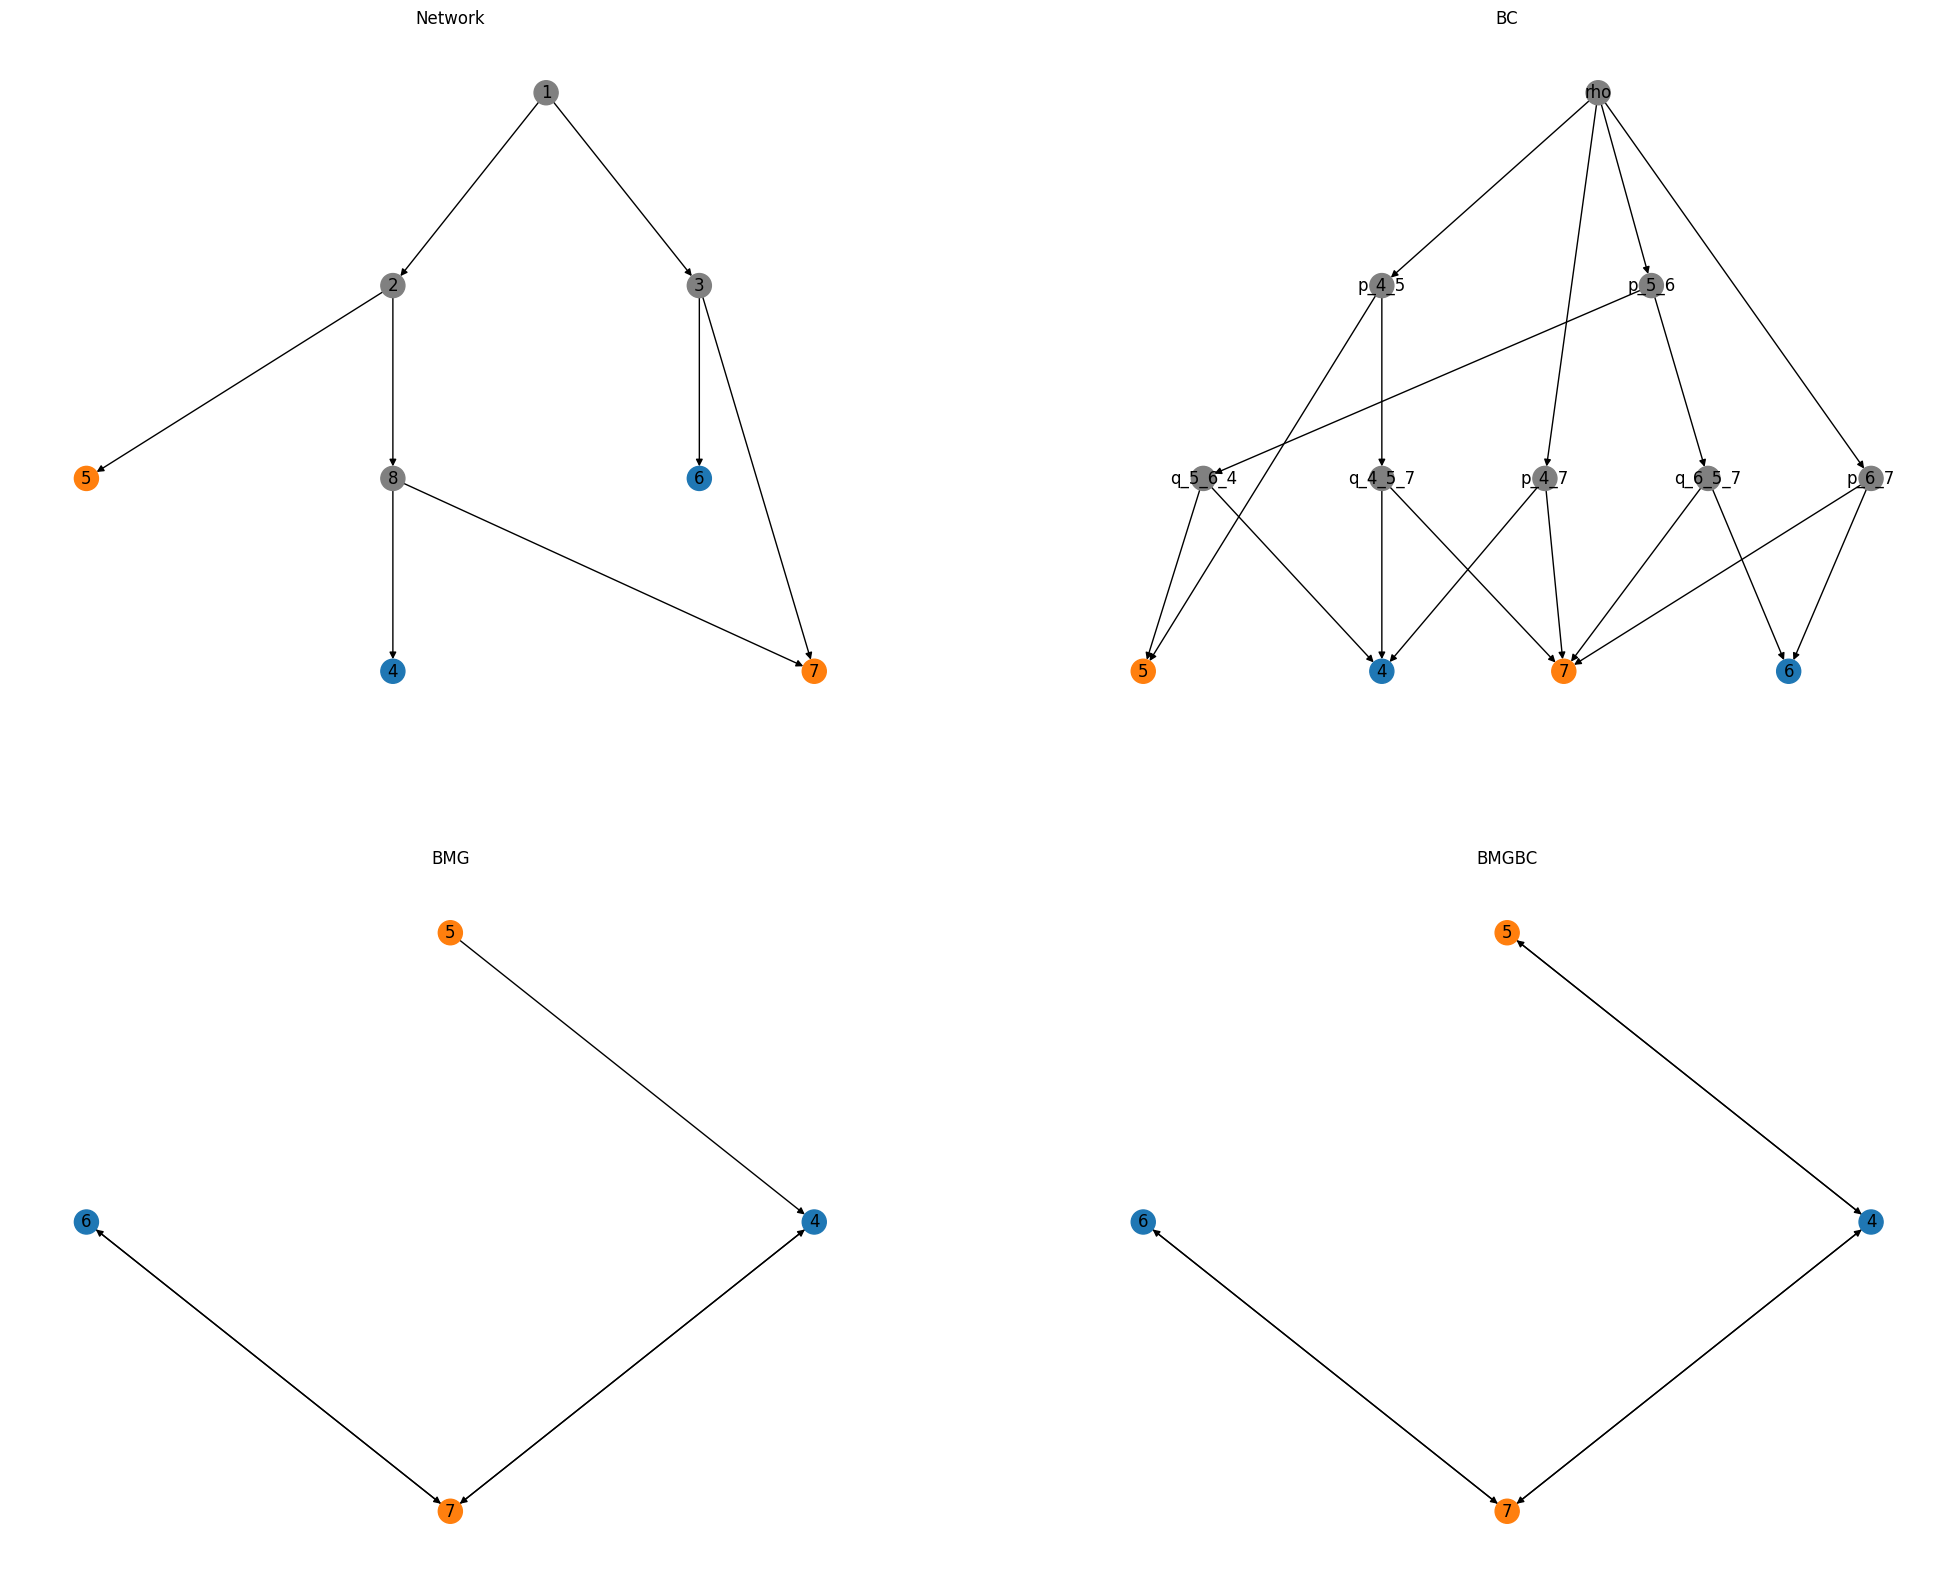

In [6]:
MISC_Functions.breakBMG(seed = 2,nSpecies = 2,mode = "weak")